# TreeAIBox — Python API Example

This notebook demonstrates the standalone Python API for LiDAR-based forest analysis.

## Prerequisites

```bash
pip install -e ".[viz]"
```

In [1]:
import numpy as np

# Core API
from treeaibox import (
    tree_filtering, tree_location, post_peak_extraction,
    tree_offset, stem_clustering, crown_clustering,
    stem_classification, crown_offset,
    create_dtm, tree_statistics, clean_small_clusters,
)

# I/O
from treeaibox_io import load_point_cloud, save_point_cloud

# Model management
from treeaibox_models import list_available_models

# Visualization
from treeaibox_viz import plot_point_cloud, plot_tree_locations, plot_classification

## 1. List Available Models

In [2]:
models = list_available_models()
print(f"Available models ({len(models)}):")
for m in models:
    print(f"  - {m}")

Available models (22):
  - treefiltering_tls_esegformer3D_128_8cm(GPU3GB)
  - treefiltering_als_esegformer3D_128_15cm(GPU3GB)
  - treefiltering_als_esegformer3D_128_50cm(GPU3GB)
  - treefiltering_als_esegformer3D_128_80cm(GPU3GB)
  - treefiltering_uav_esegformer3D_128_12cm(GPU3GB)
  - urbanfiltering_als_esegformer3D_112_30cm(GPU3GB)
  - treeisonet_als_reclamation_treeloc_esegformer3D_128_10cm(GPU4GB)
  - treeisonet_als_reclamation_treeoff_esegformer3D_128_10cm(GPU4GB)
  - treeisonet_tls_boreal_stemcls_esegformer3D_128_4cm(GPU3GB)
  - treeisonet_tls_boreal_stemcls_esegformer3D_128_10cm(GPU3GB)
  - treeisonet_tls_boreal_treeloc_esegformer3D_128_10cm(GPU3GB)
  - treeisonet_tls_boreal_crownoff_esegformer3D_128_15cm(GPU4GB)
  - treeisonet_uav_mixedwood_stemcls_esegformer3D_128_8cm(GPU3GB)
  - treeisonet_uav_mixedwood_treeloc_esegformer3D_128_10cm(GPU3GB)
  - treeisonet_uav_mixedwood_crownoff_esegformer3D_128_15cm(GPU4GB)
  - woodcls_stem_tls_esegformer3D_128_10cm(GPU3GB)
  - woodcls_stem_tl

## 2. Load a Point Cloud

In [3]:
# Load your LAS/LAZ file
data = load_point_cloud(r"C:\\Users\\mdshadman_amin\\Documents\\data\\opentopo_armycamp\\points.laz")
points = data["points"]  # (N, 3) numpy array


# For demonstration, create a synthetic point cloud
# np.random.seed(42)
# n_points = 10000
# x = np.random.rand(n_points) * 50
# y = np.random.rand(n_points) * 50
# z = np.random.rand(n_points) * 20
# points = np.column_stack([x, y, z])
# print(f"Point cloud shape: {points.shape}")

In [4]:
fields = data['fields']

In [5]:
fields['classification']

array([1, 1, 1, ..., 1, 2, 2], dtype=uint8)

## 3. Visualize the Raw Point Cloud

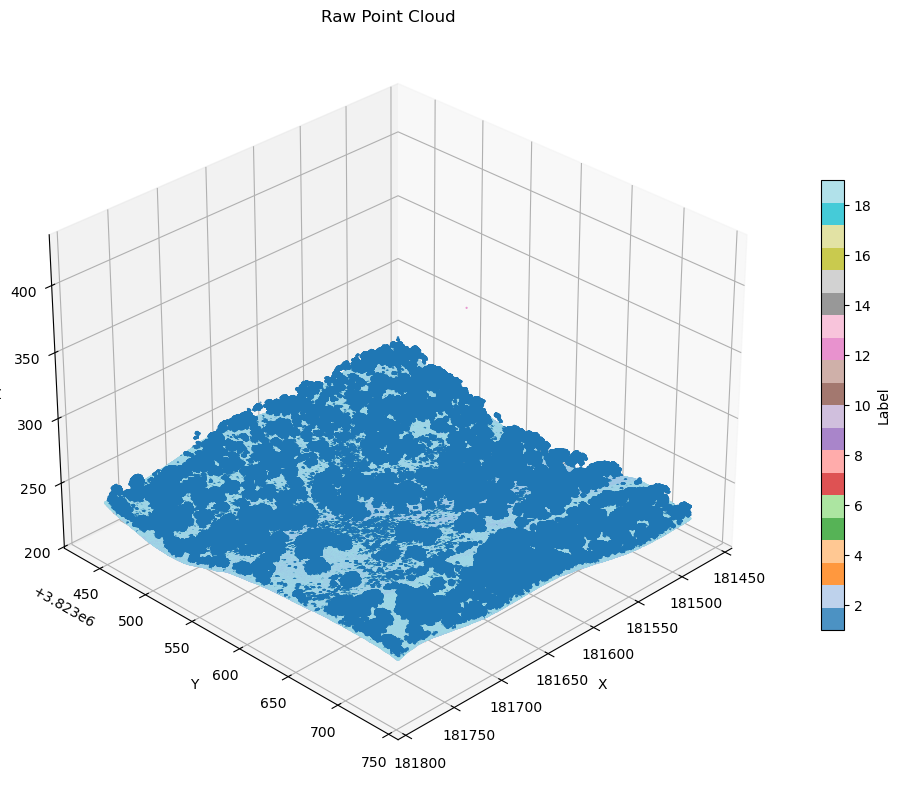

In [18]:
fig = plot_point_cloud(points, title="Raw Point Cloud", labels=fields['classification'])

In [31]:
print(np.unique(fields['classification']))

[ 1  2  7 12 19]


In [37]:
np.shape(points)

(7088610, 3)

## 4. Tree Filtering (Ground/Vegetation Separation)

This step classifies points into ground/understory (label 1) and overstory vegetation (label 2).

**Note:** This requires a GPU and a pre-trained model. The model will be downloaded automatically on first use.

  URL: https://github.com/NRCan/TreeAIBox/releases/download/v1.0/treefiltering_uav_esegformer3D_128_12cm_GPU3GB.pth
  Destination: C:\Users\mdshadman_amin\.treeaibox\models\treefiltering_uav_esegformer3D_128_12cm(GPU3GB).pth
  Download complete: C:\Users\mdshadman_amin\.treeaibox\models\treefiltering_uav_esegformer3D_128_12cm(GPU3GB).pth


Processing:   0%|          | 0/100 [00:00<?]C:\Users\mdshadman_amin\Documents\dev\cloudcompy_treeai\modules\filter\componentFilter.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

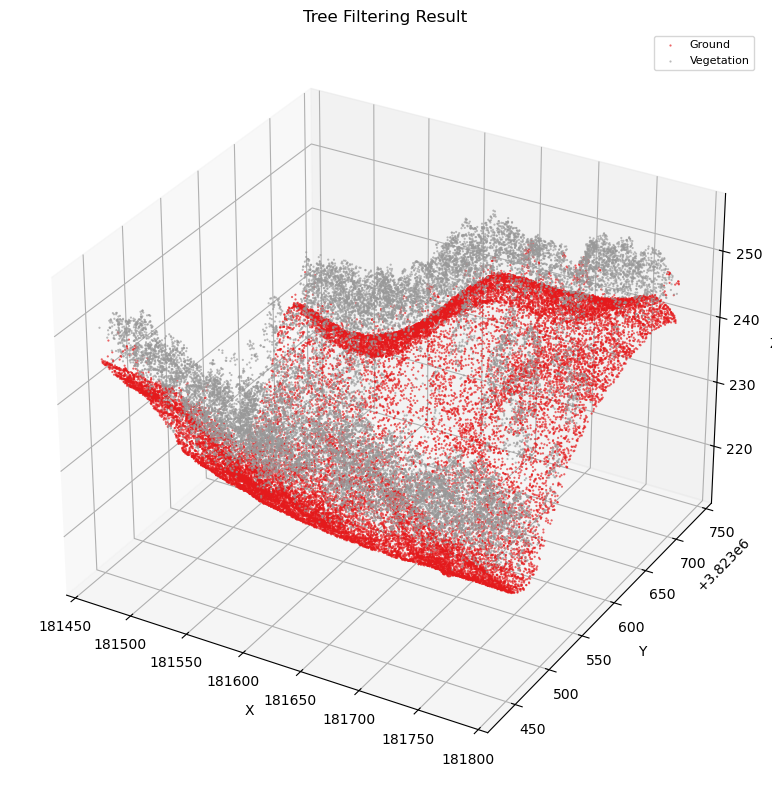

In [25]:
filter_model = "treefiltering_uav_esegformer3D_128_12cm(GPU3GB)"
filter_labels = tree_filtering(points, filter_model, use_cuda=True)
fig = plot_classification(points, filter_labels, 
                          class_names={1: "Ground", 2: "Vegetation"},
                          title="Tree Filtering Result")

c:\ProgramData\miniconda3\envs\treeai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing:   0%|          | 0/100 [00:00<?]c:\ProgramData\miniconda3\envs\treeai\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\mdshadman_amin\Documents\dev\cloudcompy_treeai\modules\filter\componentFilter.py:149: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md

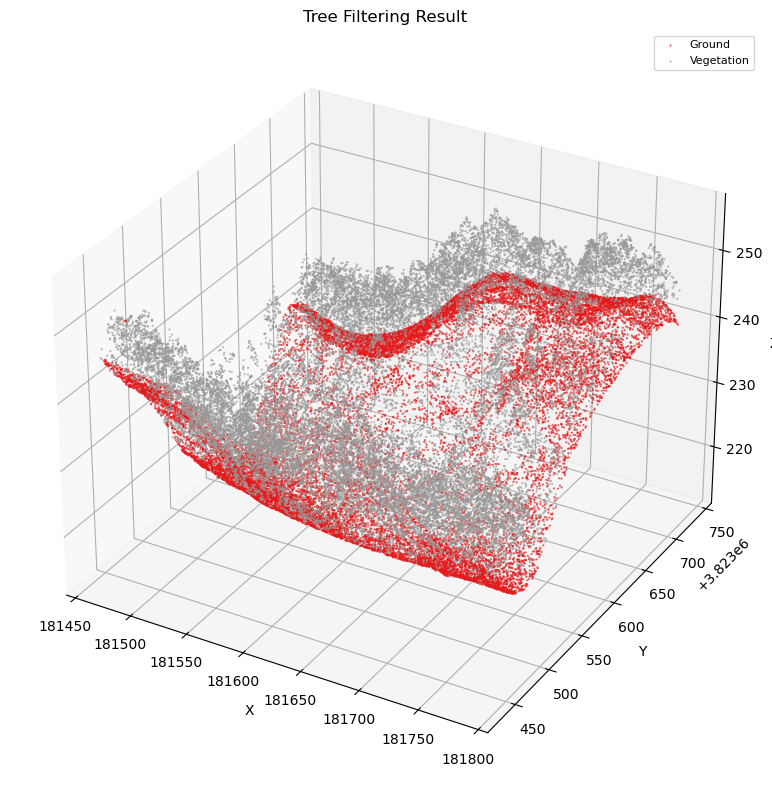

In [6]:
filter_model = "treefiltering_als_esegformer3D_128_15cm(GPU3GB)"
filter_labels = tree_filtering(points, filter_model, use_cuda=False)
fig = plot_classification(points, filter_labels, 
                          class_names={1: "Ground", 2: "Vegetation"},
                          title="Tree Filtering Result")

## 5. Tree Location Detection

Detect tree tops or stem bases from the point cloud.

In [ ]:
loc_model = "treeisonet_als_reclamation_treeloc_esegformer3D_128_10cm(GPU4GB)"
stem_preds = tree_location(points, loc_model, if_stem=True)
stemmed_tree_tops = post_peak_extraction(stem_preds, K=5, nms_thresh=0.3)
print(f"Detected {len(stemmed_tree_tops)} trees")
fig = plot_tree_locations(points, stemmed_tree_tops, title="Detected Trees with predicted Stems")

In [ ]:
loc_model = "treeisonet_als_reclamation_treeloc_esegformer3D_128_10cm(GPU4GB)"
preds = tree_location(points, loc_model, if_stem=False)
tree_tops = post_peak_extraction(preds, K=5, nms_thresh=0.3)
print(f"Detected {len(tree_tops)} trees")
fig = plot_tree_locations(points, tree_tops, title="Detected Trees with predicted Tree Tops")

## 6. Tree Segmentation

Assign each point to an individual tree using offset-based segmentation.

In [ ]:
off_model = "treeisonet_als_reclamation_treeoff_esegformer3D_128_10cm(GPU4GB)"
tree_ids = tree_offset(points, tree_tops[:, :3], off_model)
fig = plot_point_cloud(points, labels=tree_ids, title="Individual Tree Segmentation")

## 7. Save Results

In [ ]:
# Save with scalar fields
save_point_cloud("output.laz", points, fields={
    "treefilter": filter_labels,
    "tree_id": tree_ids,
})
print("Done! Results would be saved to output.laz")

## 8. CloudComPy Integration (Optional)

If you have CloudComPy installed in your conda environment, you can convert between CloudComPy and numpy:

In [ ]:
# from treeaibox_io import cloudcompy_to_numpy, numpy_to_cloudcompy
#
# # Convert CloudComPy cloud to numpy
# data = cloudcompy_to_numpy(cc_cloud)
# points = data["points"]
#
# # Run analysis
# labels = tree_filtering(points, model_name)
#
# # Convert back to CloudComPy
# result_cloud = numpy_to_cloudcompy(points, fields={"labels": labels})